# L14 : Gamma Ray Bursts

Let's look at the latest database of Gamma Ray Bursts.
- The database can be downloaded at https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt
- You can find the physical meaning of each variable at https://user-web.icecube.wisc.edu/~grbweb_public/Variables.html

You have a cool dataset, explore it!
- Does the distribution contain different sub-populations? How many?
- What's the threshold between the classes?
- If you try two clustering methods, do you get more or less the same?
- How do methods respond to outliers?
- What variable(s) shows the multi-modality more evidently?
- Are all GRBs equally likely to be observed?

In [30]:
import requests
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import astropy.visualization.hist

from sklearn.neighbors import KernelDensity 
from scipy.signal import find_peaks
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn import preprocessing
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.preprocessing import StandardScaler

In [31]:
# Download file
r = requests.get('https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt')
with open("Summary_table.txt", 'wb') as f:
    f.write(r.content)

# Read content
data = np.loadtxt("Summary_table.txt", dtype='str',unpack='True')
# Read headers
with open("Summary_table.txt",'r') as f:
    names = np.array([n.strip().replace(" ","_") for n in f.readlines()[1].replace("#","").replace("\n","").lstrip().split('    ') if n.strip()!=''])

/var/folders/rz/tfsbd_ws6wb_56t6nv6trm9c0000gn/T/ipykernel_7213/136158517.py:7: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=50000`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  data = np.loadtxt("Summary_table.txt", dtype='str',unpack='True')


In [32]:
print(data.shape)
print(names, '\n', names.shape)

(15, 9152)
['GRB_name' 'GRB_name_Fermi' 'T0' 'ra' 'decl' 'pos_error' 'T90'
 'T90_error' 'T90_start' 'fluence' 'fluence_error' 'redshift' "'T100'"
 'GBM_located' 'mjd_(T0)'] 
 (15,)


All Data:
- 'GRB_name' : **string** - name of the GRB (i.e. GRB010513B is the second GRB on the 13th of May 2001.
- 'GRB_name_Fermi' : **string** - GRB name in the 'Fermi' format
- 'T0' : **double**, unit=[seconds] - it's the earliest trigger time of the satellites or the start of the T90 interval if it preceeds those trigger time.
- 'ra' : **double**, unit=[degrees] - Right ascension in J2000 coordinates.
- 'decl' : **double**, unit=[degrees] - Declination in J2000 coordinates.
- 'pos_error' : **double**, unit=[degrees] - 1σ error on the localisation.
- 'T90' : **double**, unit=[seconds] - Duration of the time interval during which 90% of the GRB photon counts are observed
- 'T90_error' : **double**, unit=[seconds] - Estimated 1σ error on the duration of the T90 interval.
- 'T90_start' : **double**, unit=[seconds] - UTC time that marks the start of the T90 interval.
- 'fluence' : **double**, unit=[erg/cm^2] - The time integrated total energy per unit surface. The observed value strongly depends on the energy band and thus the detector that observed the burst.
- 'fluence_error' : **double**, unit=[erg/cm^2] - Estimated 1σ error on the fluence.
- 'redshift' : **double** - Distance to the GRB.
- 'T100' : **double**, unit=[seconds] - Total time during which the GRB was observed.
- 'GBM_located' : **bool** - Indicates whether the localisation (ra, decl) was provided by the Fermi-GBM detector.
- 'mjd_(T0)' : **double**, unit=[days] - the value of 'T0' is also given in the 'Modified Julian Date' format.

In [33]:
# Data conversion
ra = np.array(data[3], dtype=float)
decl = np.array(data[4], dtype=float)
pos_error = np.array(data[5], dtype=float)
T90 = np.array(data[6], dtype=float)
T90_error = np.array(data[7], dtype=float)
fluence = np.array(data[9], dtype=float)
fluence_error = np.array(data[10], dtype=float)
redshift = np.array(data[11], dtype=float)

## GRB sky map

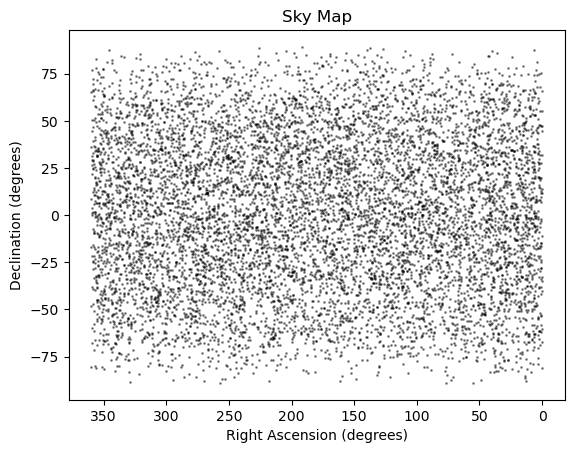

In [34]:
plt.scatter(ra, decl, s=1, color='black', marker='o', alpha=0.4)
plt.xlabel('Right Ascension (degrees)')
plt.ylabel('Declination (degrees)')
plt.title('Sky Map')
plt.gca().invert_xaxis()
plt.show()

## $T_{90}$ = Duration of the time interval during which 90% of the GRB photon counts are observed

In [35]:
T90 = T90[T90 > 0] # # mask unphysical values
logT90 = np.log10(T90)

<function matplotlib.pyplot.show(close=None, block=None)>

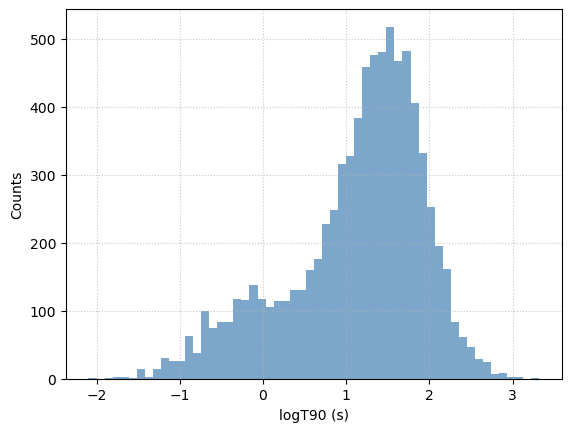

In [62]:
plt.hist(logT90, bins="fd", color='steelblue', alpha=0.7)
plt.xlabel('logT90 (s)')
plt.ylabel('Counts')
plt.grid(True, linestyle=':', alpha=0.7)
plt.show

In [63]:
def kde_sklearn(data, bandwidth, xgrid):
    kde_skl = KernelDensity(bandwidth = bandwidth)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(xgrid[:, np.newaxis]) # sklearn returns log(density)
    return np.exp(log_pdf)


In [64]:
bwrange = np.linspace(0.01,1.0, 20) # Test 20 bandwidths from 0.1 to 1.0
print(bwrange)

X_train = logT90[:,None]

K = 5 # Do 5-fold cross validation
grid = GridSearchCV(KernelDensity(), {'bandwidth': bwrange}, cv= K) # Try each bandwidth with K-folds
grid.fit(X_train) 
h_opt = grid.best_params_['bandwidth']
print(h_opt)

[0.01       0.06210526 0.11421053 0.16631579 0.21842105 0.27052632
 0.32263158 0.37473684 0.42684211 0.47894737 0.53105263 0.58315789
 0.63526316 0.68736842 0.73947368 0.79157895 0.84368421 0.89578947
 0.94789474 1.        ]
0.11421052631578947


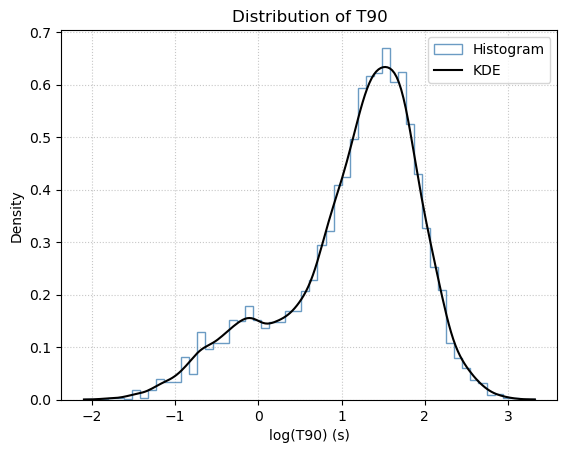

In [65]:
# Fit
xgrid = np.linspace(logT90.min(), logT90.max(), 200)  # scala lineare nello spazio log

pdf = kde_sklearn(logT90, bandwidth=h_opt, xgrid=xgrid)
plt.hist(logT90, bins="fd", color='steelblue', alpha=0.8, density=True, histtype="step", label='Histogram')
plt.plot(xgrid, pdf, label='KDE', color='black', linewidth=1.5)
plt.title('Distribution of T90')
plt.xlabel('log(T90) (s)')
plt.ylabel('Density')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()

In [66]:
peaks_T90, _ = find_peaks(pdf)
# T90 peaks
print(f"\nNumber of peaks - T90: {len(peaks_T90)}")
print("Peaks at T90:")
for val in 10**xgrid[peaks_T90]:
    print(f"  - {val:.2f} s")


Number of peaks - T90: 2
Peaks at T90:
  - 0.78 s
  - 33.49 s


There seems to be 2 population of GRB in terms of the time duration (T90).

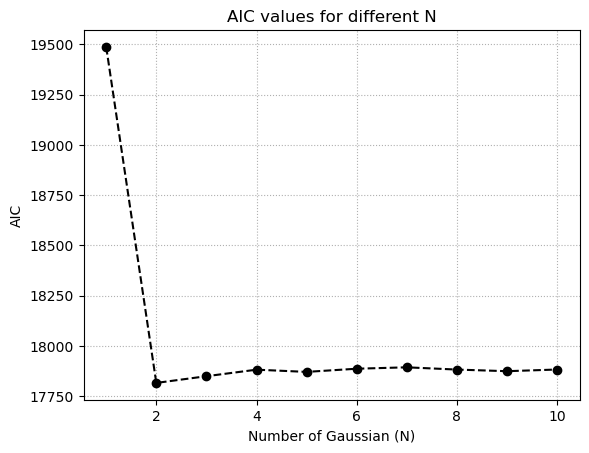

Best model : 2 gaussian


In [67]:
AIC_values = []

for i in range(1,11):
    model = GaussianMixture(i)
    model.fit(X_train)
    AIC = model.aic(X_train)
    AIC_values.append(AIC)

AIC = np.array(AIC_values)
n_best_index = np.argmin(AIC)
n_best = range(1, 11)[n_best_index]
best_aic = AIC[n_best_index] 

plt.plot(range(1,11), AIC, marker='o', color='black', linestyle='--')
plt.title("AIC values for different N")
plt.xlabel("Number of Gaussian (N)")
plt.ylabel("AIC")
plt.grid(True,linestyle = ":")
plt.show()

print("Best model :", n_best , "gaussian")

[ 1.48255166 -0.0296865 ]


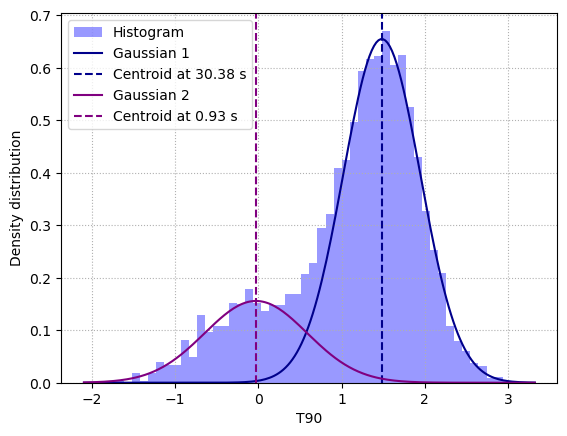

In [68]:
gmm = GaussianMixture(n_components=n_best)
gmm.fit(X_train)

xgrid = np.linspace(logT90.min(), logT90.max(), 200).reshape(-1,1)
weights = gmm.weights_
means = gmm.means_.flatten()
print(means)
covariances = gmm.covariances_.flatten()

plt.hist(logT90, bins="fd", color='blue', density=True, alpha=0.4, edgecolor='none', label='Histogram')
colors = ["darkblue", "purple"]
for i in range(n_best):
    mean = means[i]
    gauss = weights[i] * (1 / np.sqrt(2 * np.pi * covariances[i])) * np.exp(-0.5 * ((xgrid - means[i]) ** 2) / covariances[i])
    plt.plot(xgrid, gauss, color=colors[i], label=f'Gaussian {i+1}')
    plt.axvline(mean, color=colors[i], linestyle='--', label=f'Centroid at {10**mean:.2f} s')

plt.xlabel("T90")
plt.ylabel("Density distribution")
plt.legend()
plt.grid(True, linestyle=":")
plt.show()


## Redshift

In [69]:
z = redshift[redshift > 0] # mask unphysical values

<function matplotlib.pyplot.show(close=None, block=None)>

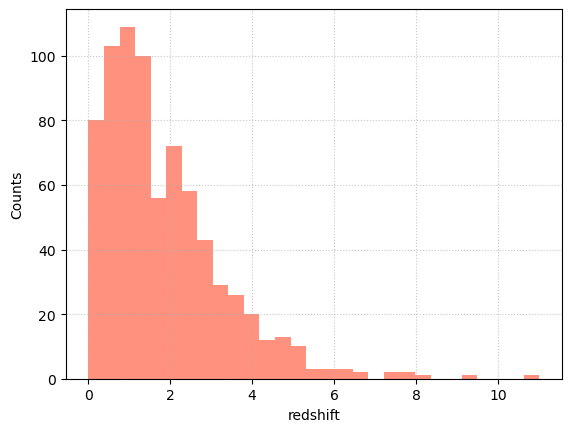

In [72]:
plt.hist(z, bins="fd", color='tomato', alpha=0.7)
plt.xlabel('redshift')
plt.ylabel('Counts')
plt.grid(True, linestyle=':', alpha=0.7)
plt.show

In [73]:
bwrange = np.linspace(0.01,1.0, 40) # Test 20 bandwidths from 0.1 to 1.0
print(bwrange)

X_train = z[:,None]

K = 5 # Do 5-fold cross validation
grid = GridSearchCV(KernelDensity(), {'bandwidth': bwrange}, cv= K) # Try each bandwidth with K-folds
grid.fit(X_train) 
h_opt = grid.best_params_['bandwidth']
print(h_opt)

[0.01       0.03538462 0.06076923 0.08615385 0.11153846 0.13692308
 0.16230769 0.18769231 0.21307692 0.23846154 0.26384615 0.28923077
 0.31461538 0.34       0.36538462 0.39076923 0.41615385 0.44153846
 0.46692308 0.49230769 0.51769231 0.54307692 0.56846154 0.59384615
 0.61923077 0.64461538 0.67       0.69538462 0.72076923 0.74615385
 0.77153846 0.79692308 0.82230769 0.84769231 0.87307692 0.89846154
 0.92384615 0.94923077 0.97461538 1.        ]
0.46692307692307694


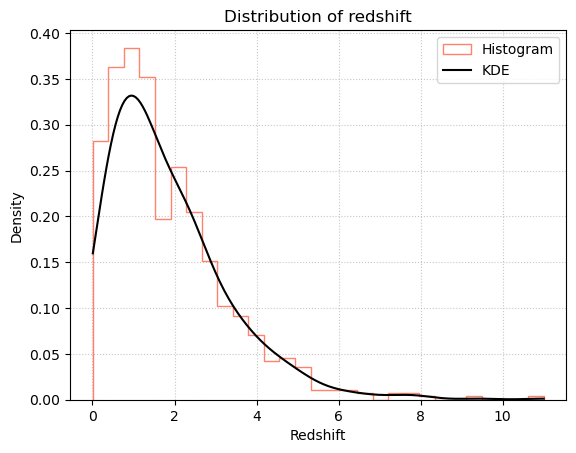

In [74]:
# Fit
xgrid = np.linspace(z.min(), z.max(), 200)  # scala lineare nello spazio log

pdf = kde_sklearn(z, bandwidth=h_opt, xgrid=xgrid)
plt.hist(z, bins="fd", color='tomato', alpha=0.8, density=True, histtype="step", label='Histogram')
plt.plot(xgrid, pdf, label='KDE', color='black', linewidth=1.5)
plt.title('Distribution of redshift')
plt.xlabel('Redshift')
plt.ylabel('Density')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()

In [75]:
peaks_z, _ = find_peaks(pdf)
print(f"\nNumber of peaks - redshift: {len(peaks_z)}")
print("Peaks at z:")
for val in xgrid[peaks_z]:
    print(f"  - {val:.2f}")


Number of peaks - redshift: 3
Peaks at z:
  - 0.95
  - 7.58
  - 9.34


## Fluence = The time integrated total energy per unit surface.

In [76]:
fluence = fluence[fluence>0] # mask unphysical values
logF = np.log10(fluence)

<function matplotlib.pyplot.show(close=None, block=None)>

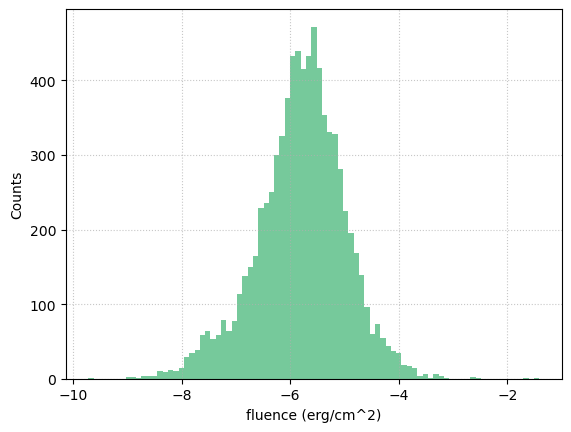

In [77]:
plt.hist(logF, bins="fd", color='mediumseagreen', alpha=0.7)
plt.xlabel('fluence (erg/cm^2)')
plt.ylabel('Counts')
plt.grid(True, linestyle=':', alpha=0.7)
plt.show

In [78]:
bwrange = np.linspace(0.01,1.0, 20) # Test 20 bandwidths from 0.1 to 1.0
print(bwrange)

X_train = logF[:,None]

K = 5 # Do 5-fold cross validation
grid = GridSearchCV(KernelDensity(), {'bandwidth': bwrange}, cv= K) # Try each bandwidth with K-folds
grid.fit(X_train) 
h_opt = grid.best_params_['bandwidth']
print(h_opt)

[0.01       0.06210526 0.11421053 0.16631579 0.21842105 0.27052632
 0.32263158 0.37473684 0.42684211 0.47894737 0.53105263 0.58315789
 0.63526316 0.68736842 0.73947368 0.79157895 0.84368421 0.89578947
 0.94789474 1.        ]
0.32263157894736844


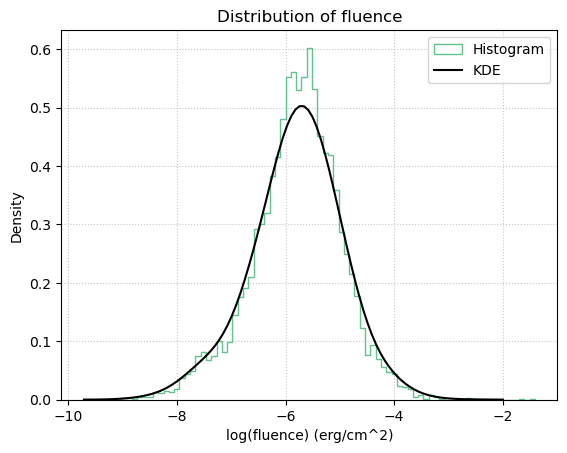

In [79]:
# Fit
xgrid = np.linspace(logF.min(), -2, 100)  # scala lineare nello spazio log

pdf = kde_sklearn(logF, bandwidth=h_opt, xgrid=xgrid)
plt.hist(logF, bins="fd", color='mediumseagreen', alpha=0.8, density=True, histtype="step", label='Histogram')
plt.plot(xgrid, pdf, label='KDE', color='black', linewidth=1.5)
plt.title('Distribution of fluence')
plt.xlabel('log(fluence) (erg/cm^2)')
plt.ylabel('Density')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()

In [80]:
peaks_F, _ = find_peaks(pdf)

print(f"\nNumber of peaks - fluence: {len(peaks_F)}")
print("Peaks at Fluence:")
for val in 10**xgrid[peaks_F]:
    print(f"  - {val:.2e} erg/cm^2")


Number of peaks - fluence: 1
Peaks at Fluence:
  - 1.82e-06 erg/cm^2


In terms of fluence, we cannot distinguish 2 different populations of GRB . We have to investigate further.

# Clustering
## K-mean clustering

Let's see if we can study the bimodality of GRBs in a 2D-space.

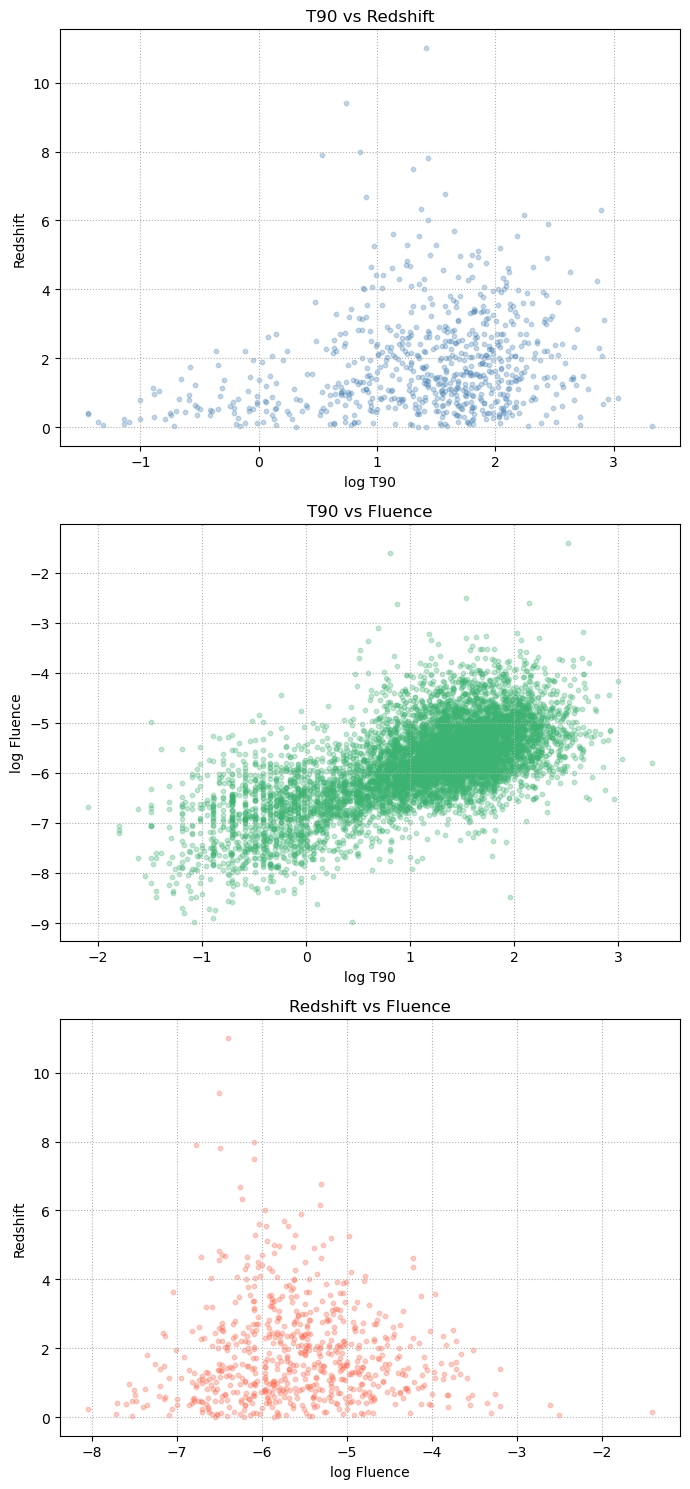

In [81]:
T90_data = np.array(data[6], dtype=float)
redshift_data = np.array(data[11], dtype=float)
fluence_data = np.array(data[9], dtype=float)

mask_T90_z = np.logical_and(T90_data>0, redshift_data>0) 
mask_T90_f = np.logical_and(T90_data>0, fluence_data>0)
mask_z_f = np.logical_and(redshift_data>0, fluence_data>0)


# ---- PLOT ----
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(7, 15))

# 1: relation between T90 and redshift
T90_1 = T90_data[mask_T90_z]
z_1 = redshift_data[mask_T90_z]

ax1.scatter(np.log10(T90_1), z_1, s=10, alpha=0.3, color='steelblue')
ax1.set_xlabel('log T90')
ax1.set_ylabel('Redshift')
ax1.set_title('T90 vs Redshift')
ax1.grid(linestyle=':')

# 2: relation between T90 and fluence
T90_2 = T90_data[mask_T90_f]
f_2 = fluence_data[mask_T90_f]

ax2.scatter(np.log10(T90_2), np.log10(f_2), s=10, alpha=0.3, color='mediumseagreen')
ax2.set_xlabel('log T90')
ax2.set_ylabel('log Fluence')
ax2.set_title('T90 vs Fluence')
ax2.grid(linestyle=':')

# 2: relation between redshift and fluence
z_3 = redshift_data[mask_z_f]
f_3 = fluence_data[mask_z_f]

ax3.scatter(np.log10(f_3), z_3, s=10, alpha=0.3, color='tomato')
ax3.set_ylabel('Redshift')
ax3.set_xlabel('log Fluence')
ax3.set_title('Redshift vs Fluence')
ax3.grid(linestyle=':')

plt.tight_layout()
plt.show()

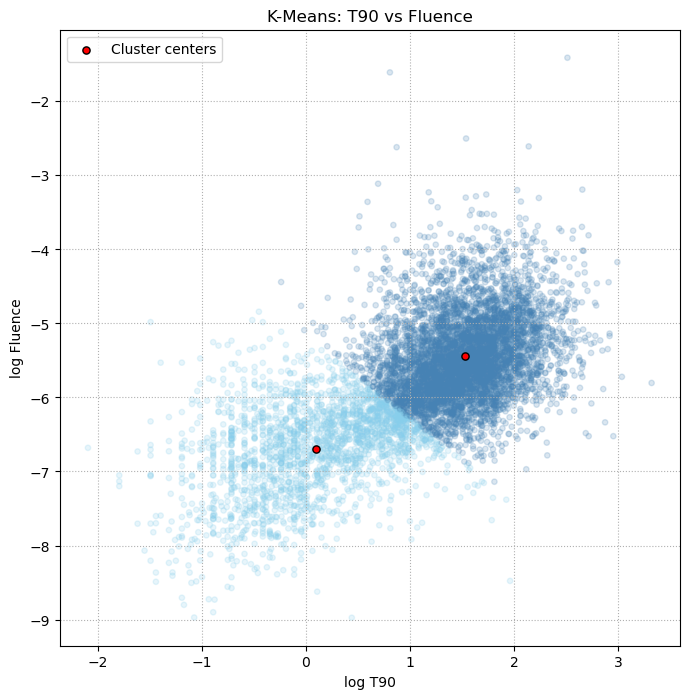

In [82]:
# Prepare 2D feature space: log10(T90) and log10(Fluence)
log_T90_2 = np.log10(T90_2)
log_flu_2 = np.log10(f_2)
X = np.column_stack((log_T90_2, log_flu_2))

n_clusters = 2
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k_means = KMeans(n_clusters=n_clusters, random_state=42)
labels = k_means.fit_predict(X_scaled)
cluster_centers_scaled = k_means.cluster_centers_
cluster_centers = scaler.inverse_transform(cluster_centers_scaled)

colors = ['skyblue' if label == 0 else 'steelblue' for label in labels]

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot()

ax.scatter(log_T90_2, log_flu_2, s=15, alpha=0.2, c=colors)
ax.scatter(cluster_centers[:, 0], cluster_centers[:, 1], 
            color='red', edgecolors='k', marker='o', s=27, label='Cluster centers')
ax.set_xlabel('log T90')
ax.set_ylabel('log Fluence')
ax.set_title('K-Means: T90 vs Fluence')
ax.grid(linestyle=':')
ax.legend()

In [83]:
# Extract centroids from log10 space
logT90_centroids = cluster_centers[:, 0]  # x-axis is log10(T90)

# Find the midpoint in log space
logT90_threshold = np.mean(logT90_centroids)

# Convert to linear T90
T90_threshold = 10**logT90_threshold

print(f"Estimated T90 separation threshold: {T90_threshold:.2f} s (log10: {logT90_threshold:.2f})")

Estimated T90 separation threshold: 6.46 s (log10: 0.81)


## Mean-Shift Clustering

In [137]:
log_T90_2 = np.log10(T90_2)
log_flu_2 = np.log10(f_2)
X = np.column_stack((log_T90_2, log_flu_2))

'''
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

bwrange = np.linspace(0.1, 1, 20)

K = 5 # Do 5-fold cross validation
grid = GridSearchCV(KernelDensity(), {'bandwidth': bwrange}, cv= K)

# Cross-Validation
grid.fit(X_scaled)

best_bandwidth = grid.best_params_['bandwidth']
print(f"Miglior bandwidth trovata con 5-Fold CV: {best_bandwidth:.4f}")
'''
mean_shift = MeanShift(bandwidth=0.8, bin_seeding=True, cluster_all=False)
labels = mean_shift.fit_predict(X_scaled)
cluster_centers_scaled = mean_shift.cluster_centers_
cluster_centers = scaler.inverse_transform(cluster_centers_scaled)

unique_labels = np.unique(labels)
n_clusters = len(unique_labels)
print(f"Numero di cluster individuati dal Mean-Shift: {n_clusters}")

Numero di cluster individuati dal Mean-Shift: 6


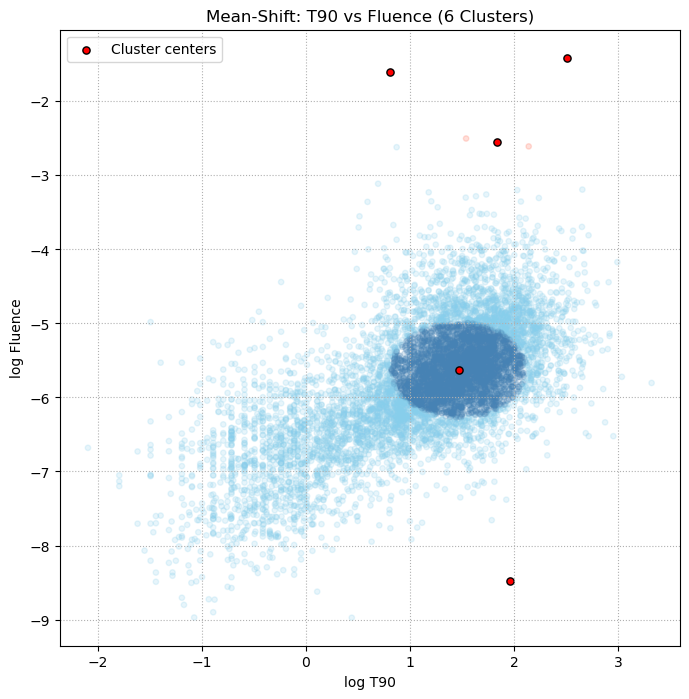

In [138]:
custom_colors = ['skyblue', 'steelblue', 'tomato', 'mediumseagreen', 'purple', 'gold', 'orchid']
if n_clusters <= len(custom_colors):
    color_map = {label: custom_colors[i] for i, label in enumerate(unique_labels)}
else:
    color_map = {label: plt.cm.tab10(i % 10) for i, label in enumerate(unique_labels)}

colors = [color_map[label] for label in labels]

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot()

ax.scatter(log_T90_2, log_flu_2, s=15, alpha=0.2, c=colors)
ax.scatter(cluster_centers[:, 0], cluster_centers[:, 1], color='red', edgecolors='k', marker='o', s=27, label='Cluster centers')
ax.set_xlabel('log T90')
ax.set_ylabel('log Fluence')
ax.set_title(f'Mean-Shift: T90 vs Fluence ({n_clusters} Clusters)')
ax.grid(linestyle=':')
ax.legend()
plt.show()

The algorthm fails to find the centroids.
I tried also with CV but i didn't find a better result.

# Errors

In [139]:
T90_data = np.array(data[6], dtype=float)
T90_error_data = np.array(data[7], dtype=float)
fluence_data = np.array(data[9], dtype=float)
fluence_error_data = np.array(data[10], dtype=float)

T90_err_corr = T90_error_data[mask_T90_f]
fluence_err_corr = fluence_error_data[mask_T90_f]

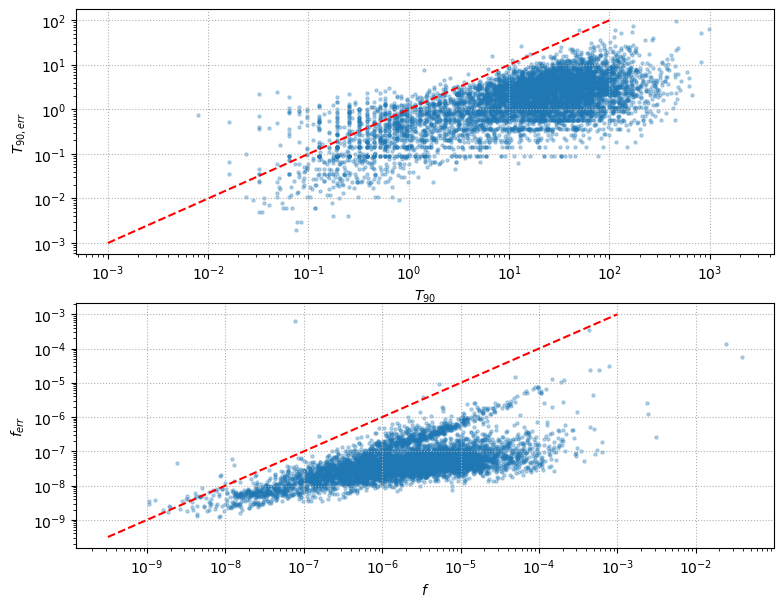

In [140]:
xgrid_t = np.logspace(-3, 2, 4) 
xgrid_f = np.logspace(-9.5, -3, 4)

fig, ax = plt.subplots(2, figsize=(9, 7))

ax[0].scatter(T90_2, T90_err_corr, alpha=0.3, s=5)
ax[0].plot(xgrid_t, xgrid_t, '--', c='red')
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_xlabel('$T_{90}$')
ax[0].set_ylabel('$T_{90, err}$')
ax[0].grid(linestyle = ':')

ax[1].scatter(f_2, fluence_err_corr, alpha=0.3, s=5)  # in both cases check if the error is of the order of the measurement
ax[1].plot(xgrid_f, xgrid_f, '--', c='red')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_xlabel('$f$')
ax[1].set_ylabel('$f_{err}$'); 
ax[1].grid(linestyle = ':')

Errors are significantly smaller than the respective quantities.